In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import re
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm


/Users/z3344650/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Users/z3344650/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [2]:
# Read in data from the Nulisa assay which was sent to us by Bofei
df = pd.read_excel('../data/NULISA_for_upload.xlsx')
df.head()

,targetName,P08_C1_D1_BMA,P08_C1_D1_PB,P08_C7_D1_BMA,P08_C7_D1_PB,P24_C1_D1_BMA,P24_C1_D1_PB,P24_C7_D1_BMA,P24_C7_D1_PB,P12_C1_D1_BMA,...,IPC3,NC1,NC2,NC3,NC4,RNBMA_Plasma,RNPB_Plasma,SC1,SC2,SC3
0,AGER,8.098874,12.815814,10.048087,13.426360,10.186972,13.409686,9.607677,12.971496,10.819983,...,13.287857,0.000000,0.000000,0.000000,0.000000,14.652822,15.761617,13.515206,13.430871,13.215132
1,AGRP,7.261311,11.599770,9.653722,13.281680,9.498240,12.211211,10.164315,13.604866,9.289948,...,13.287857,4.197841,4.243510,0.000000,4.827565,12.537522,12.795884,13.320905,13.332838,13.281140
2,ANGPT1,11.176965,13.711416,11.570059,11.973600,11.134398,12.117352,10.437689,12.194923,9.876157,...,13.183936,6.291575,5.703534,6.492616,6.009174,12.041054,12.818809,13.341584,13.315648,13.046785
3,ANGPT2,8.961332,12.817818,9.927943,12.801492,11.676046,14.589588,11.971372,15.528098,9.929931,...,13.257715,0.000000,1.506642,2.048571,0.000000,12.311747,13.277203,13.408156,13.351494,13.179535
4,ANXA1,9.855022,11.558501,9.068268,11.336655,9.376385,9.848232,9.008491,9.886488,9.602541,...,13.287857,9.460188,9.281864,8.860607,8.714064,8.498531,10.190912,13.472023,13.352042,12.968113


In [3]:
# Transpose the df so that it easier to work with 
df.index = df['targetName']
df = df.iloc[:, 1:]
df = df.T
df

# select blood and bone marrow samples from the oral aza trial (these have _BMA or _PB in the title and lack 'RN')
df = df.loc[(df.index.str.contains('_BMA') | df.index.str.contains('_PB'))  & (~df.index.str.contains('RN')), :]

df.head()

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,TREM1,TREM2,VCAM1,VEGFA,VEGFC,VEGFD,VSNL1,VSTM1,WNT16,WNT7A
P08_C1_D1_BMA,8.098874,7.261311,11.176965,8.961332,9.855022,8.826391,10.476133,10.957482,6.862759,8.990968,...,8.726599,7.940766,9.272499,11.652502,10.575666,8.022063,9.163231,10.833751,9.306676,6.368683
P08_C1_D1_PB,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,13.143437,12.017396,12.941936,15.142156,13.385485,7.592040,11.853413,14.683010,12.931866,8.744185
P08_C7_D1_BMA,10.048087,9.653722,11.570059,9.927943,9.068268,9.235046,9.005682,11.481258,7.992722,9.794737,...,9.923594,9.151399,10.754465,11.196261,10.928972,7.842120,9.814674,11.318856,10.098527,7.128281
P08_C7_D1_PB,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,12.639026,12.237741,13.337745,14.208861,13.273854,7.704273,11.770859,11.012886,13.143388,8.900478
P24_C1_D1_BMA,10.186972,9.498240,11.134398,11.676046,9.376385,9.196032,7.792804,11.939582,9.500984,10.703933,...,10.474709,9.921123,11.156053,11.185332,11.645861,7.479362,9.699821,9.703087,9.618251,7.059484


In [4]:
# Add some useful details to the dataframe, this information is encoded in the sample name (index)
# and added to the df using for loops

samp = ['BMA' if 'BMA' in i else 'PB' for i in df.index]
df['sample_type'] = samp
del samp

timepoint = ['C1D1' if 'C1_D1' in i else 'C7D1' if 'C7_D1' in i else 'C12D29' if 'C12_D29' in i else None for i in df.index]

df['timepoint'] = timepoint
del timepoint

pid = [i.split('_')[0] for i in df.index]
df['pid'] = pid

del pid

In [5]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows = 40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
#patient_info['PID'] = patient_info['PID'].astype(str)

# # Create dictionaries so that I can add information to the dataframe such as 
# # diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))
    
# # Use the dictionaries to add clinical outcomes to the dataframe
df['diagnosis'] = df['pid'].map(diagnosis_dx)
df['outcome_6'] = df['pid'].map(outcome_C6_dx)
df['outcome_12'] = df['pid'].map(outcome_C12_dx)    

In [6]:
# Create a dataframe with only blood values
df_pb = df.loc[df.index.str.contains('PB'), :]
df_pb.shape

(35, 253)

In [7]:
# Remove the additional blood sample
df_pb = df_pb.loc[df_pb.index != 'P04_C12_D29_PB', :]
df_pb.head(10)

targetName,AGER,AGRP,ANGPT1,ANGPT2,ANXA1,AREG,BDNF,BMP7,BST2,C1QA,...,VSNL1,VSTM1,WNT16,WNT7A,sample_type,timepoint,pid,diagnosis,outcome_6,outcome_12
P08_C1_D1_PB,12.815814,11.599770,13.711416,12.817818,11.558501,9.357486,15.225674,11.779913,11.363372,12.427062,...,11.853413,14.683010,12.931866,8.744185,PB,C1D1,P08,MDS,non-responder_2,non-responder_2
P08_C7_D1_PB,13.426360,13.281680,11.973600,12.801492,11.336655,9.546682,11.610879,12.108913,11.263604,12.575250,...,11.770859,11.012886,13.143388,8.900478,PB,C7D1,P08,MDS,non-responder_2,non-responder_2
P24_C1_D1_PB,13.409686,12.211211,12.117352,14.589588,9.848232,10.399768,10.552040,12.523015,12.473277,13.134511,...,11.696018,11.279987,12.565671,8.744706,PB,C1D1,P24,AML,non-responder_2,NaN
P24_C7_D1_PB,12.971496,13.604866,12.194923,15.528098,9.886488,10.453888,10.212944,12.194522,12.178838,13.449840,...,11.777130,10.086519,12.867314,9.052809,PB,C7D1,P24,AML,non-responder_2,NaN
P12_C1_D1_PB,13.698245,12.930173,12.565802,13.068282,9.113249,10.701452,13.841984,12.688355,12.596144,14.120495,...,12.207011,11.916969,12.884989,9.620725,PB,C1D1,P12,MDS,responder_1,responder_1
P12_C7_D1_PB,13.972684,14.652388,13.903779,12.825494,9.158899,10.342438,15.547902,12.540153,10.867731,13.872861,...,11.888821,8.459874,13.044832,10.165778,PB,C7D1,P12,MDS,responder_1,responder_1
P04_C1_D1_PB,13.202248,12.799180,11.184085,13.495764,9.587354,9.972133,6.338712,12.494508,10.816165,13.212585,...,11.640657,14.101869,12.684559,8.967549,PB,C1D1,P04,AML,responder_1,non-responder_2
P04_C7_D1_PB,11.483475,13.588755,15.166637,12.762694,9.003599,10.488438,16.030052,11.906930,10.458220,12.582448,...,11.912233,10.490137,12.431912,10.015726,PB,C7D1,P04,AML,responder_1,non-responder_2
P03_C1_D1_PB,13.836740,12.825042,12.486342,13.045114,10.678130,11.410011,12.055060,12.184086,10.315101,13.280309,...,11.262336,12.724190,13.024659,9.760402,PB,C1D1,P03,MDS,responder_1,responder_1
P03_C7_D1_PB,13.629345,13.055261,12.687346,13.191082,10.282887,11.752607,13.527198,12.043008,10.914491,12.790688,...,11.260321,12.576448,13.079476,10.034908,PB,C7D1,P03,MDS,responder_1,responder_1


In [8]:
# Read in a datasheet which details cytokine receptor combinations
cytokines = pd.read_excel('../data/2026_02_25_receptor_cytokine_combinations.xlsx', sheet_name= 'receptor_cytokine_combo')
cytokines.columns

Index(['Receptor', 'Cytokine'], dtype='object')

In [9]:
# Create a new column which details the change in the ratio of a cytokine 
# to its receptor or inhibitor (e.g. the ratio of IL-18 to Il-18BP)
for _, row in cytokines.iterrows():
    mol1 = row['Cytokine']
    mol2 = row['Receptor']
    
    if mol1 in df_pb.columns and mol2 in df_pb.columns:
        df_pb[f'{mol1}_{mol2}'] = df_pb[mol1] - df_pb[mol2]

In [10]:
for x, y in enumerate(df_pb.columns):
    print(x, y)

0 AGER
1 AGRP
2 ANGPT1
3 ANGPT2
4 ANXA1
5 AREG
6 BDNF
7 BMP7
8 BST2
9 C1QA
10 CALCA
11 CCL1
12 CCL11
13 CCL13
14 CCL14
15 CCL15
16 CCL16
17 CCL17
18 CCL19
19 CCL2
20 CCL20
21 CCL21
22 CCL22
23 CCL23
24 CCL24
25 CCL25
26 CCL26
27 CCL27
28 CCL28
29 CCL3
30 CCL4
31 CCL5
32 CCL7
33 CCL8
34 CD200
35 CD200R1
36 CD27
37 CD274
38 CD276
39 CD3E
40 CD4
41 CD40
42 CD40LG
43 CD46
44 CD70
45 CD80
46 CD83
47 CD93
48 CEACAM5
49 CHI3L1
50 CLEC4A
51 CNTF
52 CRP
53 CSF1
54 CSF1R
55 CSF2
56 CSF2RB
57 CSF3
58 CSF3R
59 CST7
60 CTF1
61 CTLA4
62 CTSS
63 CX3CL1
64 CXADR
65 CXCL1
66 CXCL10
67 CXCL11
68 CXCL12
69 CXCL13
70 CXCL14
71 CXCL16
72 CXCL2
73 CXCL3
74 CXCL5
75 CXCL6
76 CXCL8
77 CXCL9
78 EGF
79 EPO
80 FASLG
81 FGF19
82 FGF2
83 FGF21
84 FGF23
85 FLT1
86 FLT3LG
87 FLT4
88 FTH1
89 FURIN
90 GDF15
91 GDF2
92 GFAP
93 GRN
94 GZMA
95 GZMB
96 HAVCR1
97 HGF
98 HLA-DRA
99 ICAM1
100 ICOSLG
101 IFNA1; IFNA13
102 IFNA2
103 IFNB1
104 IFNG
105 IFNL1
106 IFNL2; IFNL3
107 IFNW1
108 IKBKG
109 IL10
110 IL10RB
111 IL11
112 

In [11]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

categories = df_pb.columns[253:]

def run_mixed_model(df, column):
    model_data = df[['pid', 'timepoint', column]].dropna().copy()
    model_data.columns = ['pid', 'timepoint', 'value']
    model_data['timepoint'] = (model_data['timepoint'] == 'C7D1').astype(int)  # encode the timepoints as 0/1
    
    model = smf.mixedlm('value ~ timepoint', model_data, groups=model_data['pid'])
    result = model.fit(reml=False)
    return result.pvalues['timepoint'], result.params['timepoint']  # p-value and effect size

pval_rows = []
for outcome in ['responder_1', 'non-responder_2']:
    subset = df_pb[df_pb['outcome_6'] == outcome]
    for col in categories:
        p, coef = run_mixed_model(subset, col)
        pval_rows.append({'outcome': outcome, 'molecule': col, 'pval': p, 'coef': coef})

pval_df = pd.DataFrame(pval_rows)

# BH correction within each group
_, pval_df['pval_adj'], _, _ = multipletests(pval_df['pval'], method='fdr_bh')

/Users/z3344650/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/z3344650/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/z3344650/opt/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
def add_significance_stars(ax, x, p_value, max_val, fontsize=8):
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    
    bar_width = 0.35
    line_y = 5 #max_val + 0.15   # just above the tallest bar
    star_y = 5.5#line_y + 0.3
    
    ax.hlines(y=line_y, xmin=x - bar_width/2, xmax=x + bar_width/2,
              colors='black', linewidth=0.8, linestyle='-')
    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

In [13]:
# Filter pval_df to keep molecules with a low p-value
to_keep = []
for x, y in zip(pval_df['molecule'], pval_df['pval_adj']):
    if y <= 0.05:
        to_keep.append(x)
to_keep.extend(['IL18_IL18BP', 'IL18_IL18R1', 'CD40LG_CD40'])

pval_df = pval_df.loc[pval_df['molecule'].isin(to_keep), :]

In [14]:
# Check the pval_df for this outcome
print(pval_df[pval_df['outcome'] == outcome][['molecule', 'pval', 'pval_adj']].head(20))

# Check a specific lookup
row = pval_df[(pval_df['outcome'] == 'responder') & (pval_df['molecule'] == categories[0])]
print(row)

             molecule      pval  pval_adj
30        CD40LG_CD40  0.304524  0.570982
31         CSF1_CSF1R  0.003433  0.041194
32         CSF3_CSF3R  0.000607  0.018215
33        IL18_IL18BP  0.804822  0.932128
34        IL18_IL18R1  0.839615  0.932906
48  TNFSF13_TNFRSF13B  0.067338  0.310789
50   TNFSF13_TNFRSF17  0.146276  0.437659
57        S100A9_AGER  0.304030  0.570982
Empty DataFrame
Columns: [outcome, molecule, pval, coef, pval_adj]
Index: []


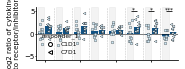

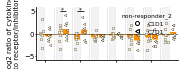

In [15]:
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

bar_width = 0.35
time_offsets = {'C1D1': -bar_width/2 - 0.025, 'C7D1': bar_width/2 + 0.025}
categories = pval_df[pval_df['outcome'] == 'responder_1']['molecule'].tolist()
colors = {'non-responder_2': '#fe9003', 'responder_1': '#115284'}

dot_colors = {'non-responder_2': '#FFF3CD', 'responder_1': '#D0E8F5'}

markers = {'C1D1': 'o', 'C7D1': '<'}
x_positions = np.arange(len(categories))
mean_values = df_pb.groupby(['outcome_6', 'timepoint'])[categories].mean()

for outcome in ['responder_1', 'non-responder_2']:
    fig, ax = plt.subplots(figsize=(2.4, 0.8))

    # Grey background bars for both timepoints
    for offset in time_offsets.values():
        if offset <= 0:
            ax.bar(x_positions + offset, height=12, bottom=-6,
                   width=bar_width,
                   facecolor='lightgrey', edgecolor='lightgrey',
                   alpha=0.25, zorder=0)

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]

        ax.bar(x_positions + offset, values, bar_width,
               facecolor=colors[outcome], edgecolor=None,
               alpha=1, label=time, zorder=2)

        ax.hlines(values,
                  xmin=x_positions + offset - bar_width/2,
                  xmax=x_positions + offset + bar_width/2,
                  colors=colors[outcome],
                  linewidth=0.75, alpha=0.75, zorder=3)

        subset = df_pb[(df_pb['outcome_6'] == outcome) & (df_pb['timepoint'] == time)]
        for i, category in enumerate(categories):
            x_jitter = np.random.normal(0, 0.05, size=len(subset))
            ax.scatter(x_positions[i] + offset + x_jitter,
                       subset[category],
                       marker=markers[time],
                       facecolor= dot_colors[outcome], edgecolor='black',
                       linewidth=0.25, alpha=1, s=8, zorder=4)

    # Axes formatting
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    for i in range(len(categories) - 1):
        ax.axvline(x=i + bar_width + 0.15,
                   color='silver', linestyle='--', linewidth=0.5)

    # ax.set_xticks(x_positions)
    ax.set_xticklabels('', rotation=90, fontsize=7)
    ax.set_ylim(-6, 6)
    ax.set_xlim(-0.5, len(categories) - 0.5)
    ax.tick_params(axis='both', labelsize=7, pad=0.1, length=1.5)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('Log2 ratio of cytokine\nto receptor/inhibitor', fontsize=7)

    legend_handles = [
        Line2D([0], [0], marker=markers[time], color='black',
               markerfacecolor='white', markersize=4,
               linewidth=0, label=time)
        for time in time_offsets
    ]
    ax.legend(handles=legend_handles, fontsize=6, title=outcome,
              title_fontsize=6, frameon=False)

    # Significance stars
    for i, category in enumerate(categories):
        row = pval_df[(pval_df['outcome'] == outcome) & (pval_df['molecule'] == category)]
        if len(row) > 0:
            p = row['pval_adj'].values[0]
            max_val = mean_values.loc[outcome, :][category].max()
            add_significance_stars(ax, x_positions[i], p, max_val, fontsize=6)

    fig.tight_layout(pad=0.1)
    fig.savefig(f'../graphs/{outcome}_c1d1_v_c7d1_cytokines_receptors.pdf',
                 bbox_inches='tight', pad_inches=0.01, dpi=600)
    # plt.show()